In [48]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
import os


load_dotenv()

os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")


In [49]:
llm = ChatGoogleGenerativeAI(
    model="gemini-flash-latest"
)
llm

ChatGoogleGenerativeAI(profile={'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), model='gemini-flash-latest', client=<google.genai.client.Client object at 0x000002BAE2557E50>, default_metadata=(), model_kwargs={})

In [51]:
llm.invoke("What is the capital of France?")

AIMessage(content=[{'type': 'text', 'text': 'The capital of France is **Paris**.', 'extras': {'signature': 'EskBCsYBAb4+9vu++DKqN5yfyHtfZDAasbOoYRDt2Lp5AnICknYdTE17pujnUcX7enN9+h0GSuCC52bymSD8+zh8zThfFQqDE8xeTiSIRyX7JzCnjKZJoyWnl074fFt/Tk9sB0ICVZAXf4UZcPWAZEOTsCnCDMfTa1r5kJAGxjpV+VVWluLVfYPw2ZGRI28Ff4sB3Aj2aiPqklZAGiPV998mNQYDGaZ4KEHxM5AMyjF/9XXgl/8dYLoN8jXN6KTOMEL0fJ7CCZpxOSU6'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3-flash-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d5b5b-204f-7400-808e-82369fa15c47-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 43, 'total_tokens': 51, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 35}})

In [52]:
#Pydantic Schema
from pydantic import BaseModel, Field

class graph_schema(BaseModel):

    topic: str = Field(description="The topic of the message")
    post: str = Field(description="The content of the message")
    curated_post: str = Field(description="The curated content of the message")

demo_obj = graph_schema(
    topic="AI",
    post="AI is transforming the world.",
    curated_post="AI is revolutionizing various industries by automating tasks and providing insights."

)



In [65]:
from pydantic import BaseModel, Field

class graph_schema(BaseModel):
    topic: str = Field(description="The topic of the message")
    post: str = ""
    curated_post: str = ""

def _to_text(content):
    if isinstance(content, list):
        return "".join(
            part.get("text", "") if isinstance(part, dict) else str(part)
            for part in content
        )
    return str(content)

def create_post(state):
    topic = state.topic
    result = llm.invoke(f"Write a LinkedIn post about {topic}")
    return {"post": _to_text(result.content)}

def curate_post(state):
    post = state.post
    result = llm.invoke(f"Improve this LinkedIn post: {post}")
    return {"curated_post": _to_text(result.content)}

In [66]:
#Step 3: Create the State Graph
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

#Adding Nodes
graph.add_node("create_post", create_post)
graph.add_node("curate_post", curate_post)

#Adding Edges
graph.add_edge(START, "create_post")
graph.add_edge("create_post", "curate_post")
graph.add_edge("curate_post", END)

pydantic_graph = graph.compile()


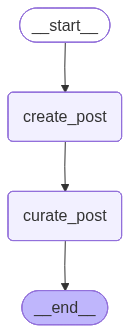

In [67]:
#Step 4 Compile the graph
from IPython.display import Image, display
first_graph = graph.compile()

Image(first_graph.get_graph().draw_mermaid_png())

In [68]:
pydantic_graph.invoke({
    "topic": "AI",
    "post": "",
    "curated_post": ""
})

{'topic': 'AI',
 'post': 'To give you the best result, I’ve drafted three different types of LinkedIn posts depending on your goal: **Thought Leadership**, **Practical/Productivity**, and **Human-Centric.**\n\nChoose the one that best fits your personal brand!\n\n---\n\n### Option 1: The Thought Leadership Approach\n**Goal:** To position yourself as a forward-thinker who understands the "big picture."\n\n**Headline:** AI isn’t a replacement. It’s an evolution. 🚀\n\nWe’ve spent decades teaching humans to understand computers. We are now entering an era where computers finally understand humans.\n\nThe conversation is shifting from "Will AI take my job?" to "How can I do my job better with AI?" \n\nIn my view, the real winners of the AI revolution won\'t be the ones with the best algorithms—they’ll be the ones with the best:\n1️⃣ **Curiosity:** The ability to ask the right questions (Prompt Engineering).\n2️⃣ **Critical Thinking:** The ability to vet and verify AI-generated output.\n3️⃣ 